# Complex Gradient + Computational Graph

This notebook builds a non-trivial expression using `Value.eml`, computes gradients with backprop, and visualizes the computational graph.

In [1]:
import sys
sys.path.append('../')

from nanograd.engine import Value

In [4]:
# Build an expression with multiple nested eml calls
a = Value(1.2)
b = Value(2.5)
c = Value(0.7)
d = Value(3.3)

left = Value.eml(a,b)          # exp(a) - log(b)
right = Value.eml(c,d)         # exp(c) - log(d)
mix = Value.eml(left,right)    # exp(left) - log(right)
f = Value.eml(mix,Value.eml(a,c))    # final scalar output

f.backward()

print('f =', f.data)
print('df/da =', a.grad)
print('df/db =', b.grad)
print('df/dc =', c.grad)
print('df/dd =', d.grad)

f = 77969.67399831774
df/da = 2864538.491002003
df/db = -345113.0741062999
df/dc = -191520.0709839678
df/dd = 28820.074416280637


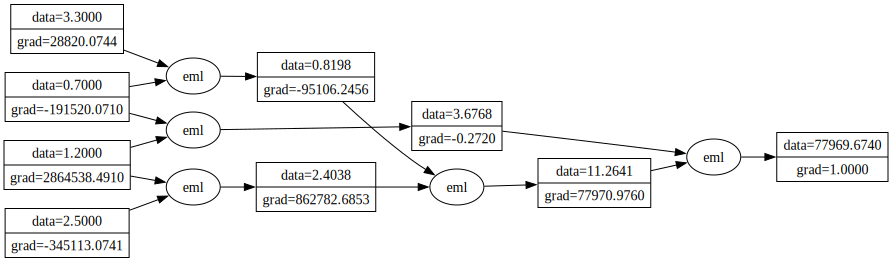

In [5]:
from graphviz import Digraph

def trace(root):
    nodes, edges = set(), set()

    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)

    build(root)
    return nodes, edges

def draw_dot(root):
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'})
    nodes, edges = trace(root)

    for n in nodes:
        uid = str(id(n))
        dot.node(uid, label=f'data={n.data:.4f} | grad={n.grad:.4f}', shape='record')
        if n._op:
            op_id = uid + n._op
            dot.node(op_id, label=n._op)
            dot.edge(op_id, uid)

    for n1, n2 in edges:
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)

    return dot

draw_dot(f)